In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
matches_df=pd.read_csv('/kaggle/input/datasets/abhaysinghrajput1111/ipl-2026-dataset/matches.csv')
deliveries_df=pd.read_csv('/kaggle/input/datasets/abhaysinghrajput1111/ipl-2026-dataset/deliveries.csv')
print('Matches shape',matches_df.shape)
print('deliveries shape',deliveries_df.shape)


Matches shape (39, 23)
deliveries shape (17477, 19)


In [66]:
print(matches_df.dtypes)
print(deliveries_df.dtypes)

match_id                        int64
date                   datetime64[ns]
venue                          object
team1                          object
team2                          object
stage                          object
toss_winner                    object
toss_decision                  object
first_ings_score                int64
first_ings_wkts               float64
second_ings_score               int64
second_ings_wkts              float64
match_result                   object
match_winner                   object
wb_runs                       float64
wb_wickets                    float64
balls_left                    float64
player_of_the_match            object
top_scorer                     object
highscore                     float64
best_bowling                   object
best_bowling_figure            object
super_over_match               object
win_margins                     int64
dtype: object
match_no                     int64
date                datetime64[ns]
stag

In [3]:
matches_df.tail(10)


,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,match_winner,wb_runs,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,super_over_match
29,30,"April 20, 2026","Narendra Modi Stadium, Ahmedabad",GT,MI,League,GT,Bowl,199.0,5.0,...,MI,99.0,NaN,25.0,Tilak Varma,Tilak Varma,101.0,Ashwani Kumar,4--24,No
30,31,"April 21, 2026","Rajiv Gandhi International Stadium, Hyderabad",SRH,DC,League,DC,Bowl,242.0,2.0,...,SRH,47.0,NaN,0.0,Abhishek Sharma,Abhishek Sharma,135.0,Eshan Malinga,4--32,No
31,32,"April 22, 2026","Ekana Cricket Stadium, Lucknow",LSG,RR,League,LSG,Bowl,159.0,6.0,...,LSG,40.0,NaN,12.0,Ravindra Jadeja,Mitchell Marsh,55.0,Jofra Archer,3--20,No
32,33,"April 23, 2026","Wankhede Stadium, Mumbai",MI,CSK,League,MI,Bowl,207.0,6.0,...,CSK,103.0,NaN,6.0,Sanju Samson,Sanju Samson,101.0,Akeal Hosein,4--17,No
33,34,"April 24, 2026","M. Chinnaswamy Stadium, Bangalore",RCB,GT,League,RCB,Bowl,205.0,3.0,...,RCB,NaN,5.0,7.0,Virat Kohli,Sai Sudarshan,100.0,Rashid Khan,2--49,No
34,35,"April 25, 2026","Arun Jaitley Stadium, Delhi",DC,PBKS,League,DC,Bat,264.0,2.0,...,PBKS,NaN,6.0,7.0,KL Rahul,KL Rahul,152.0,Kuldeep Yadav,2--46,No
35,36,"April 25, 2026","Sawai Mansingh Stadium, Jaipur",RR,SRH,League,SRH,Bowl,228.0,6.0,...,SRH,NaN,5.0,9.0,Ishan Kishan,Vaibhav Sooryavanshi,103.0,Jofra Archer,2--34,No
36,37,"April 26, 2026","Narendra Modi Stadium, Ahmedabad",GT,CSK,League,GT,Bowl,158.0,7.0,...,GT,NaN,8.0,20.0,Kagiso Rabada,Sai Sudarshan,87.0,Kagiso Rabada,3--25,No
37,38,"April 26, 2026","Ekana Cricket Stadium, Lucknow",LSG,KKR,League,LSG,Bowl,155.0,7.0,...,KKR,NaN,NaN,5.0,Rinku Singh,Rinku Singh,83.0,Mohsin Khan,5--23,Yes
38,39,"April 27, 2026","Arun Jaitley Stadium, Delhi",DC,RCB,League,RCB,Bowl,75.0,10.0,...,RCB,NaN,9.0,81.0,Josh Hazlewood,Devdutt Padikkal,34.0,Josh Hazlewood,4--12,No


In [4]:
matches_df.columns

Index(['match_id', 'date', 'venue', 'team1', 'team2', 'stage', 'toss_winner',
       'toss_decision', 'first_ings_score', 'first_ings_wkts',
       'second_ings_score', 'second_ings_wkts', 'match_result', 'match_winner',
       'wb_runs', 'wb_wickets', 'balls_left', 'player_of_the_match',
       'top_scorer', 'highscore', 'best_bowling', 'best_bowling_figure',
       'super_over_match'],
      dtype='object')

In [5]:
deliveries_df.head(10)


,match_no,date,stage,venue,batting_team,bowling_team,innings,over,striker,bowler,runs_of_bat,extras,wide,legbyes,byes,noballs,wicket_type,player_dismissed,fielder
0,1,"Mar 28, 2026",League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.1,Travis Head,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN
1,1,"Mar 28, 2026",League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.2,Travis Head,Jacob Duffy,1,0,0,0,0,0,NaN,NaN,NaN
2,1,"Mar 28, 2026",League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.3,Abhishek Sharma,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN
3,1,"Mar 28, 2026",League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.4,Abhishek Sharma,Jacob Duffy,6,0,0,0,0,0,NaN,NaN,NaN
4,1,"Mar 28, 2026",League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.5,Abhishek Sharma,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN
5,1,"Mar 28, 2026",League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.6,Abhishek Sharma,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN
6,1,"Mar 28, 2026",League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,1.1,Travis Head,Bhuvneshwar Kumar,1,0,0,0,0,0,NaN,NaN,NaN
7,1,"Mar 28, 2026",League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,1.2,Abhishek Sharma,Bhuvneshwar Kumar,1,0,0,0,0,0,NaN,NaN,NaN
8,1,"Mar 28, 2026",League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,1.3,Travis Head,Bhuvneshwar Kumar,1,0,0,0,0,0,NaN,NaN,NaN
9,1,"Mar 28, 2026",League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,1.4,Abhishek Sharma,Bhuvneshwar Kumar,0,0,0,0,0,0,NaN,NaN,NaN


In [6]:
matches_df['date']=pd.to_datetime(matches_df['date'])
deliveries_df['date']=pd.to_datetime(deliveries_df['date'])

In [7]:
matches_df['first_ings_score']=matches_df['first_ings_score'].fillna(0).astype(int)
matches_df['second_ings_score']=matches_df['second_ings_score'].fillna(0).astype(int)

In [8]:
matches_df.isnull().sum()

match_id                0
date                    0
venue                   0
team1                   0
team2                   0
stage                   0
toss_winner             0
toss_decision           0
first_ings_score        0
first_ings_wkts         1
second_ings_score       0
second_ings_wkts        1
match_result            0
match_winner            1
wb_runs                24
wb_wickets             17
balls_left              1
player_of_the_match     1
top_scorer              1
highscore               1
best_bowling            1
best_bowling_figure     1
super_over_match        0
dtype: int64

In [9]:
deliveries_df.isna().sum()

match_no                0
date                    0
stage                   0
venue                   0
batting_team            0
bowling_team            0
innings                 0
over                    0
striker                 0
bowler                  0
runs_of_bat             0
extras                  0
wide                    0
legbyes                 0
byes                    0
noballs                 0
wicket_type         16598
player_dismissed    16602
fielder             16791
dtype: int64

In [10]:
matches_df.duplicated().sum()

np.int64(0)

In [11]:
deliveries_df.duplicated().sum()

np.int64(0)

In [12]:
matches_df['match_winner']=matches_df['match_winner'].fillna('No Res')

In [13]:
matches_df.isna().sum()

match_id                0
date                    0
venue                   0
team1                   0
team2                   0
stage                   0
toss_winner             0
toss_decision           0
first_ings_score        0
first_ings_wkts         1
second_ings_score       0
second_ings_wkts        1
match_result            0
match_winner            0
wb_runs                24
wb_wickets             17
balls_left              1
player_of_the_match     1
top_scorer              1
highscore               1
best_bowling            1
best_bowling_figure     1
super_over_match        0
dtype: int64

In [14]:
matches_df['match_winner'].value_counts()

match_winner
RCB       6
PBKS      6
SRH       5
GT        4
RR        4
LSG       3
DC        3
CSK       3
MI        2
KKR       2
No Res    1
Name: count, dtype: int64

In [15]:
toss_match_same=(matches_df['toss_winner']==matches_df['match_winner']).sum()
print(f"toss winner also won match:{toss_match_same} out of {len(matches_df)}")

toss winner also won match:21 out of 39


In [16]:
matches_df['toss_decision'].value_counts()

toss_decision
Bowl    34
Bat      5
Name: count, dtype: int64

In [17]:
win_by_decision=matches_df[matches_df['toss_winner']==matches_df['match_winner']]['toss_decision'].value_counts()

In [18]:
win_by_decision

toss_decision
Bowl    20
Bat      1
Name: count, dtype: int64

In [19]:
win_rate=(win_by_decision/matches_df['toss_decision'].value_counts())*100

In [20]:
win_rate

toss_decision
Bowl    58.823529
Bat     20.000000
Name: count, dtype: float64

In [21]:
matches_df['venue'].value_counts()

venue
M. Chinnaswamy Stadium, Bangalore                5
Wankhede Stadium, Mumbai                         4
Ekana Cricket Stadium, Lucknow                   4
Rajiv Gandhi International Stadium, Hyderabad    4
Eden Gardens, Kolkata                            4
Narendra Modi Stadium, Ahmedabad                 4
Arun Jaitley Stadium, Delhi                      4
Barsapara Stadium, Guwahati                      3
New PCA Cricket Stadium, Mullanpur               3
MA Chidambaram Stadium, Chennai                  3
Sawai Mansingh Stadium, Jaipur                   1
Name: count, dtype: int64

In [22]:
matches_df['stage'].value_counts()

stage
League    39
Name: count, dtype: int64

In [23]:
matches_df['win_margins']=abs(matches_df['first_ings_score']-matches_df['second_ings_score'])
matches_df[['team1','team2','match_winner','win_margins']].sort_values('win_margins')

,team1,team2,match_winner,win_margins
11,KKR,PBKS,No Res,0
37,LSG,KKR,KKR,0
15,RR,RCB,RR,1
2,RR,CSK,RR,1
13,DC,GT,GT,1
14,KKR,LSG,LSG,1
24,GT,KKR,GT,1
6,CSK,PBKS,PBKS,1
34,DC,PBKS,PBKS,1
35,RR,SRH,SRH,1


In [24]:
matches_df['player_of_the_match'].value_counts()

player_of_the_match
Priyansh Arya           2
Sameer Rizvi            2
Sanju Samson            2
Josh Hazlewood          2
Shardul Thakur          1
Jacob Duffy             1
Nitish Kumar Reddy      1
Ravi Bishnoi            1
Mohammed Shami          1
Cooper Connolly         1
Tim David               1
Yashasvi Jaiswal        1
Mukul Choudhary         1
Rashid Khan             1
Vaibhav Sooryavanshi    1
Shreyas Iyer            1
Prasidh Krishna         1
Nandre Burger           1
Phil Salt               1
Praful Hinge            1
Noor Ahmad              1
Arshdeep Singh          1
Shubman Gill            1
Tristan Stubbs          1
Eshan Malinga           1
Varun Chakravarthy      1
Tilak Varma             1
Abhishek Sharma         1
Ravindra Jadeja         1
Virat Kohli             1
KL Rahul                1
Ishan Kishan            1
Kagiso Rabada           1
Rinku Singh             1
Name: count, dtype: int64

In [25]:
matches_df['super_over_match'].value_counts()['Yes']

np.int64(1)

In [26]:
total_runs=deliveries_df.groupby('striker')['runs_of_bat'].sum().sort_values(ascending=False)

In [27]:
total_runs.head(20)

striker
Vaibhav Sooryavanshi    776
Shubman Gill            732
Sai Sudharsan           722
Virat Kohli             675
Heinrich Klaasen        624
Ishan Kishan            604
Rahul                   593
Mitchell Marsh          563
Abhishek Sharma         563
Jos Buttler             526
Dhruv Jurel             514
Prabhsimran Singh       510
Rajat Patidar           500
Shreyas Iyer            498
Cooper Connolly         491
Sanju Samson            475
Devdutt Padikkal        464
Ryan Rickelton          448
Yashasvi Jaiswal        426
Angkrish Raghuvanshi    422
Name: runs_of_bat, dtype: int64

In [28]:
total_balls=deliveries_df[deliveries_df['wide']==0].groupby('striker').size()

In [29]:
total_balls.sort_values(ascending=False)

striker
Sai Sudharsan       458
Shubman Gill        449
Virat Kohli         408
Heinrich Klaasen    390
Mitchell Marsh      345
                   ... 
KL Rahul              1
Prince Yadav          1
Jaiswal               1
Josh Hazlewood        1
Spencer Johnson       1
Length: 177, dtype: int64

In [30]:
strike_rate=(total_runs/total_balls)*100

In [31]:
strike_rate.sort_values(ascending=False)

striker
Auqib Nabi              350.000000
Vaibhav Sooryavanshi    237.308869
Madhav Tiwari           225.000000
Xavier Bartlett         223.076923
Finn Allen              214.110429
                           ...    
KL Rahul                  0.000000
Josh Hazlewood            0.000000
Mohsin Khan               0.000000
Ravi Bishnoi              0.000000
Spencer Johnson           0.000000
Length: 177, dtype: float64

In [32]:
dismissals=deliveries_df.groupby('player_dismissed')['player_dismissed'].count()
batting_average=total_runs/dismissals

In [33]:
batting_average

AM Ghazanfar               NaN
Abdul Samad          19.333333
Abhishek Sharma      40.214286
Abishek Porel        27.000000
Adam Milne                 NaN
                       ...    
Vishnu Vinod               NaN
Washington Sundar    37.700000
Will Jacks           27.800000
Xavier Bartlett      29.000000
Yashasvi Jaiswal     30.428571
Length: 177, dtype: float64

In [34]:
#boundary_per_batter=deliveries_df[deliveries_df['runs_of_bat'].isin([4,6])].groupby(['striker','runs_of_bat']).size()

In [35]:
#boundary_per_batter

In [36]:
fours=deliveries_df[deliveries_df['runs_of_bat']==4].groupby('striker').size()
sixes=deliveries_df[deliveries_df['runs_of_bat']==6].groupby('striker').size()

In [37]:
fours

striker
Abdul Samad          10
Abhishek Sharma      50
Abishek Porel        15
Aiden Markram        20
Ajinkya Rahane       25
                     ..
Vishnu Vinod          1
Washington Sundar    40
Will Jacks           12
Xavier Bartlett       2
Yashasvi Jaiswal     52
Length: 138, dtype: int64

In [38]:
sixes

striker
Abdul Samad           5
Abhishek Sharma      43
Abishek Porel         1
Aiden Markram        11
Ajinkya Rahane       18
                     ..
Vishnu Vinod          1
Washington Sundar    12
Will Jacks            9
Xavier Bartlett       2
Yashasvi Jaiswal     18
Length: 119, dtype: int64

In [39]:
fours=fours.reindex(total_runs.index,fill_value=0)
sixes=sixes.reindex(total_runs.index,fill_value=0)

In [40]:
boundary_pct=(((fours*4)+(sixes*6))/total_runs)*100
boundary_pct.dropna().sort_values(ascending=False)

striker
Ravi Singh              100.000000
Auqib Nabi              100.000000
Saurabh Dubey           100.000000
Kartik Tyagi             90.909091
Vaibhav Sooryavanshi     88.144330
                           ...    
Ashok Sharma              0.000000
Ashwani Kumar             0.000000
Arshdeep Singh            0.000000
Jaiswal                   0.000000
Natarajan                 0.000000
Length: 168, dtype: float64

In [41]:
total_runs.head(10).sort_values(ascending=False)

striker
Vaibhav Sooryavanshi    776
Shubman Gill            732
Sai Sudharsan           722
Virat Kohli             675
Heinrich Klaasen        624
Ishan Kishan            604
Rahul                   593
Mitchell Marsh          563
Abhishek Sharma         563
Jos Buttler             526
Name: runs_of_bat, dtype: int64

In [42]:
fours.sort_values(ascending=False).head(10)

striker
Sai Sudharsan           75
Shubman Gill            74
Virat Kohli             73
Vaibhav Sooryavanshi    63
Ishan Kishan            60
Rahul                   56
Prabhsimran Singh       55
Sanju Samson            53
Yashasvi Jaiswal        52
Jos Buttler             51
dtype: int64

In [43]:
sixes.sort_values(ascending=False).head(10)

striker
Vaibhav Sooryavanshi    72
Abhishek Sharma         43
Rajat Patidar           42
Ryan Rickelton          38
Mitchell Marsh          36
Shubman Gill            33
Cooper Connolly         32
Priyansh Arya           32
Ishan Kishan            32
Heinrich Klaasen        31
dtype: int64

In [44]:
deliveries_df.head()

,match_no,date,stage,venue,batting_team,bowling_team,innings,over,striker,bowler,runs_of_bat,extras,wide,legbyes,byes,noballs,wicket_type,player_dismissed,fielder
0,1,2026-03-28,League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.1,Travis Head,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN
1,1,2026-03-28,League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.2,Travis Head,Jacob Duffy,1,0,0,0,0,0,NaN,NaN,NaN
2,1,2026-03-28,League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.3,Abhishek Sharma,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN
3,1,2026-03-28,League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.4,Abhishek Sharma,Jacob Duffy,6,0,0,0,0,0,NaN,NaN,NaN
4,1,2026-03-28,League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.5,Abhishek Sharma,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN


In [45]:
runs_conceded=(deliveries_df['runs_of_bat']+deliveries_df['wide']+deliveries_df['noballs']).groupby(deliveries_df['bowler']).sum()

In [46]:
runs_conceded.sort_values(ascending=False)

bowler
Kagiso Rabada          625
Mohammed Siraj         556
Jofra Archer           546
Arshdeep Singh         535
Anshul Kamboj          527
                      ... 
Matheesha Pathirana      9
Travis Head              7
Bishnoi                  6
Abdul Samad              6
Ravindra Jadeka          1
Length: 127, dtype: int64

In [47]:
balls_bowled=deliveries_df[deliveries_df['wide']==0].groupby('bowler').size()

In [48]:
balls_bowled.sort_values(ascending=False)

bowler
Kagiso Rabada        388
Bhuvneshwar Kumar    379
Mohammed Siraj       372
Jofra Archer         361
Rashid Khan          341
                    ... 
Tim David              6
Travis Head            6
Bishnoi                1
Abdul Samad            1
Ravindra Jadeka        1
Length: 127, dtype: int64

In [49]:
wickets_taken=deliveries_df.groupby('bowler')['player_dismissed'].count()

In [50]:
wickets_taken.sort_values(ascending=False)

bowler
Bhuvneshwar Kumar    29
Jofra Archer         29
Kagiso Rabada        29
Anshul Kamboj        24
Eshan Malinga        21
                     ..
Matthew Short         0
Mayank Markande       0
Ravindra Jadeka       0
Tripurana Vijay       0
Tim David             0
Name: player_dismissed, Length: 127, dtype: int64

In [51]:
economy_rate=(runs_conceded/balls_bowled)*6

In [52]:
economy_rate.sort_values(ascending=True)

bowler
Ravindra Jadeka         6.000000
Sunil Narine            6.601942
Matheesha Pathirana     6.750000
Travis Head             7.000000
Harpreet Brar           7.500000
                         ...    
Tripurana Vijay        14.500000
Mayank Markande        15.200000
Tim David              18.000000
Bishnoi                36.000000
Abdul Samad            36.000000
Length: 127, dtype: float64

In [53]:
bowling_avg=runs_conceded/wickets_taken

In [54]:
bowling_avg.sort_values()

bowler
Travis Head             7.000000
Blessing Muzarabani    15.000000
Corbin Bosch           15.000000
Mitchell Starc         16.692308
Ashwani Kumar          17.000000
                         ...    
Matthew Short                inf
Mayank Markande              inf
Ravindra Jadeka              inf
Tripurana Vijay              inf
Tim David                    inf
Length: 127, dtype: float64

In [55]:
bowling_strike_rate=balls_bowled/wickets_taken

In [56]:
bowling_strike_rate

bowler
AM Ghazanfar        15.533333
Abdul Samad               inf
Abhinandan Singh    19.333333
Abhishek Sharma           inf
Adam Milne                inf
                      ...    
Will Jacks          26.500000
Xavier Bartlett     40.400000
Yash Raj Punja      20.000000
Yash Thakur         12.500000
Yuzvendra Chahal    19.230769
Length: 127, dtype: float64

In [57]:
print("leaderboard:\n",wickets_taken.sort_values(ascending=False).head(10))

leaderboard:
 bowler
Bhuvneshwar Kumar    29
Jofra Archer         29
Kagiso Rabada        29
Anshul Kamboj        24
Eshan Malinga        21
Rashid Khan          21
Mohammed Siraj       20
Rasikh Salam Dar     20
Prince Yadav         20
Kartik Tyagi         19
Name: player_dismissed, dtype: int64


In [58]:
bowlers_qualified=(balls_bowled[balls_bowled>=60])
economy_rate.loc[bowlers_qualified.index].sort_values().head(10)

bowler
Sunil Narine         6.601942
Jason Holder         7.532468
Saurabh Dubey        7.792208
Akeal Hosein         7.880000
Bhuvneshwar Kumar    7.915567
Axar Patel           8.090909
Jasprit Bumrah       8.132890
Mohsin Khan          8.142857
Lungi Ngidi          8.225806
Noor Ahmad           8.306189
dtype: float64

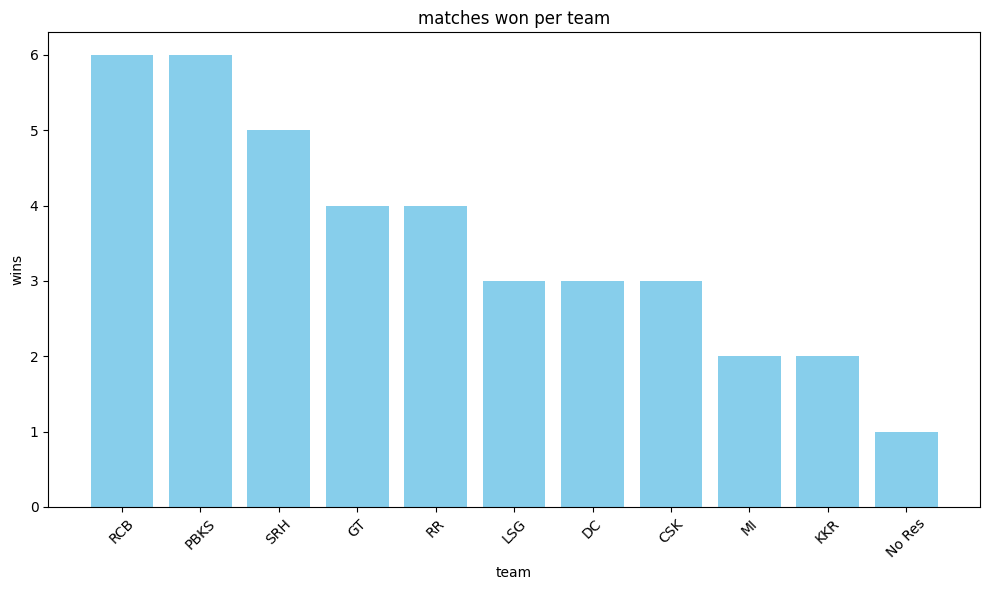

In [59]:
team_wins=matches_df['match_winner'].value_counts()

plt.figure(figsize=(10,6))
plt.bar(team_wins.index,team_wins.values,color='skyblue')
plt.title('matches won per team')
plt.xlabel('team')
plt.ylabel('wins')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

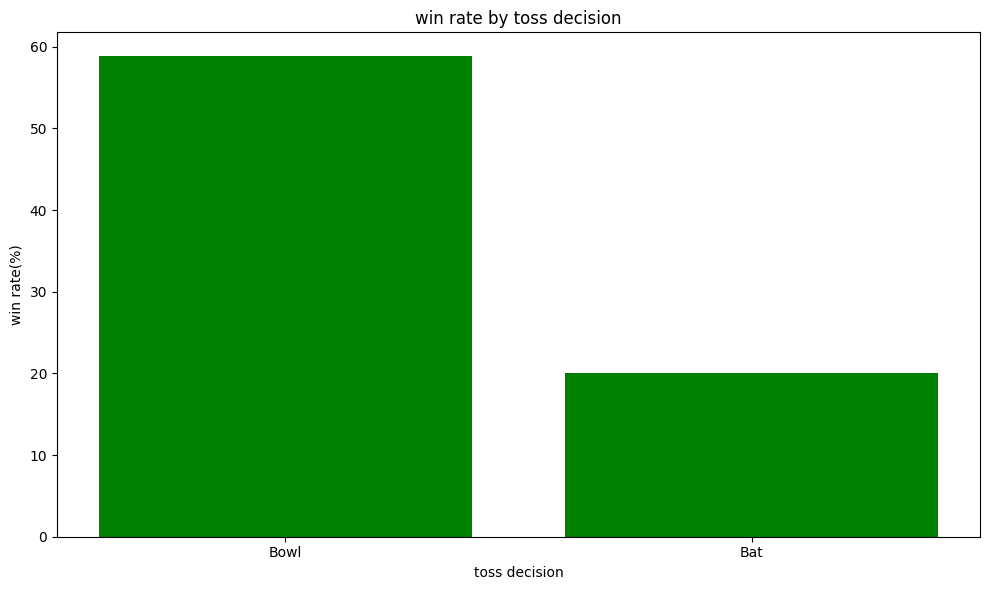

In [60]:
plt.figure(figsize=(10,6))
plt.bar(win_rate.index,win_rate.values,color='green')
plt.title('win rate by toss decision')
plt.xlabel('toss decision')
plt.ylabel('win rate(%)')
plt.tight_layout()
plt.show()

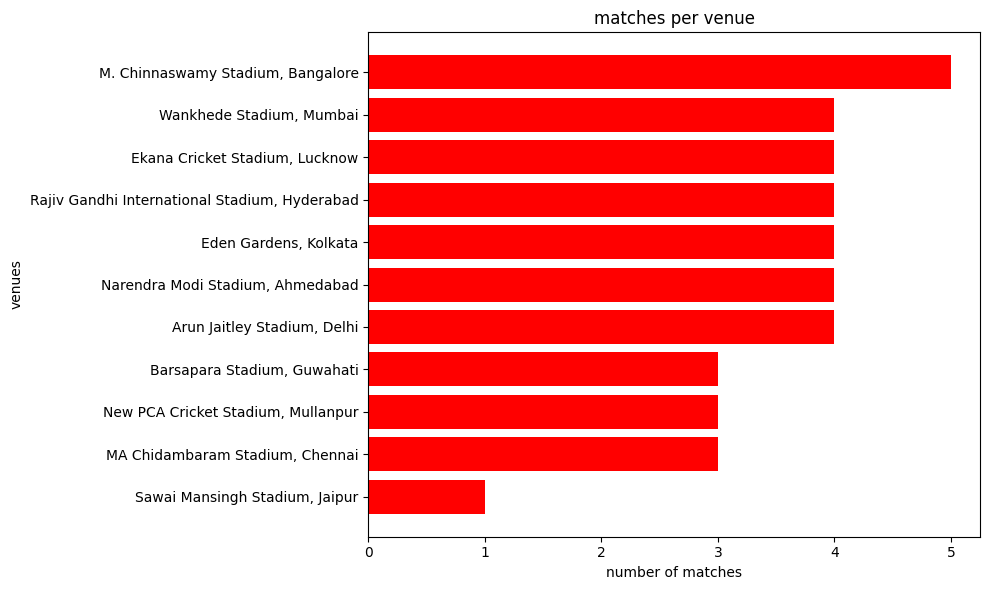

In [61]:
matches_per_venue=matches_df['venue'].value_counts()

plt.figure(figsize=(10,6))
plt.barh(matches_per_venue.index,matches_per_venue.values,color='red')
plt.title('matches per venue')
plt.xlabel('number of matches')
plt.ylabel('venues')
plt.gca().invert_yaxis()
#plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

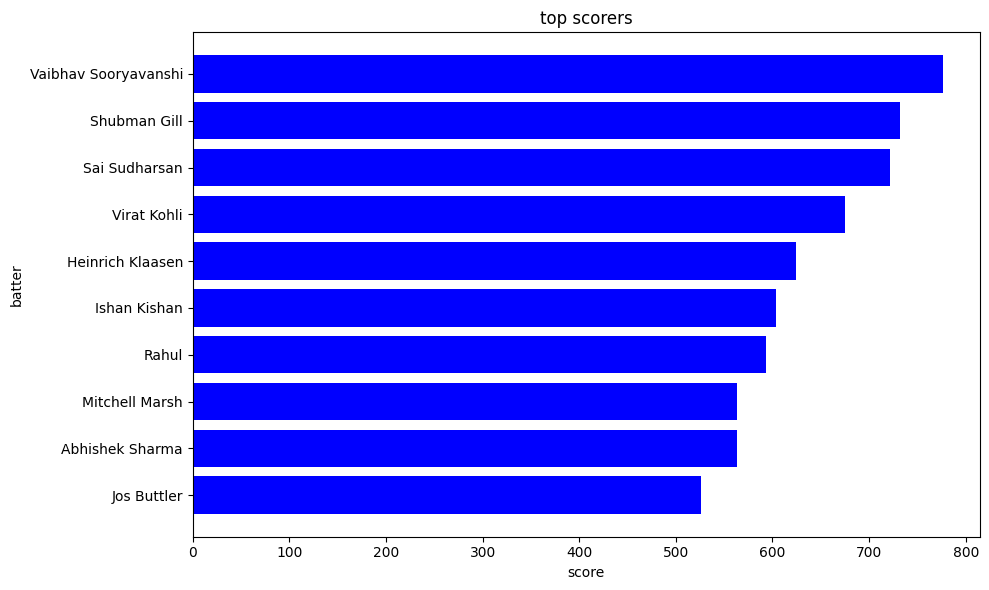

In [62]:
top_scorers=total_runs.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_scorers.index,top_scorers.values,color='blue')
plt.title('top scorers')
plt.xlabel('score')
plt.ylabel('batter')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

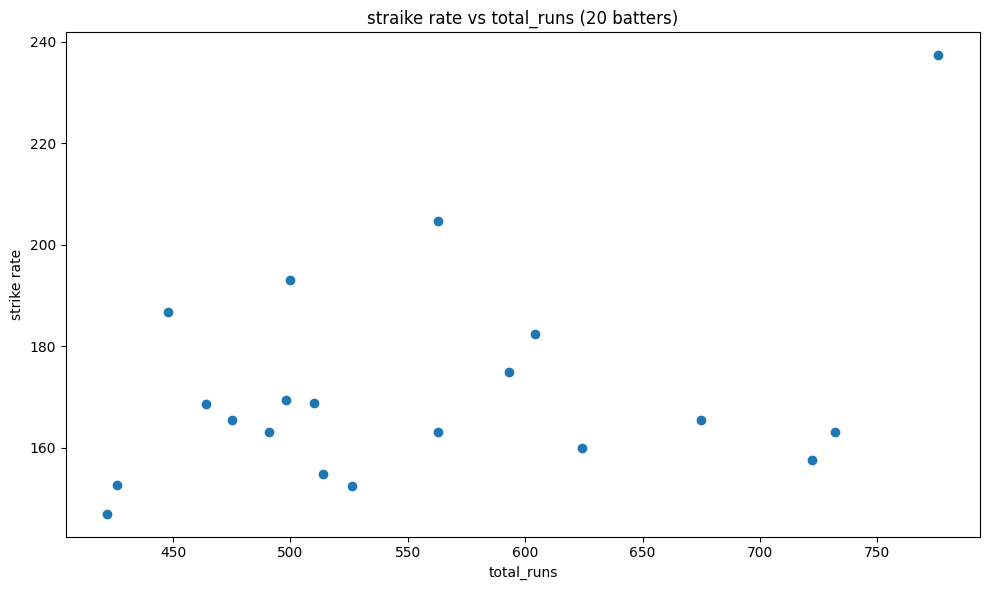

In [63]:
top_batter=total_runs.head(20)

plt.figure(figsize=(10,6))
plt.scatter(top_batter.values,strike_rate.loc[top_batter.index])
plt.title('straike rate vs total_runs (20 batters)')
plt.xlabel('total_runs')
plt.ylabel('strike rate')
plt.tight_layout()
plt.show()

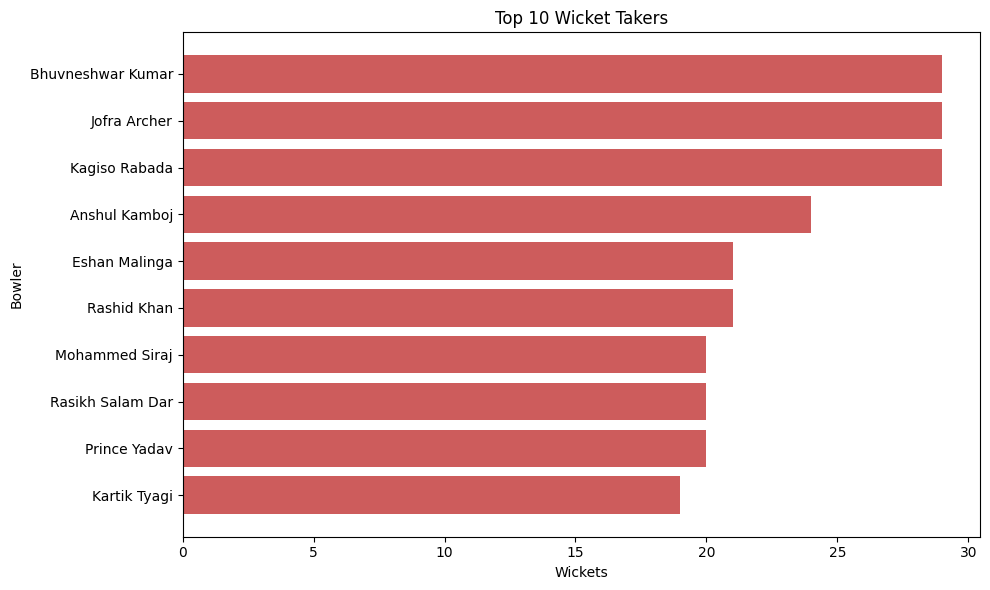

In [64]:
top_wickets = wickets_taken.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_wickets.index, top_wickets.values, color='indianred')
plt.title("Top 10 Wicket Takers")
plt.xlabel("Wickets")
plt.ylabel("Bowler")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

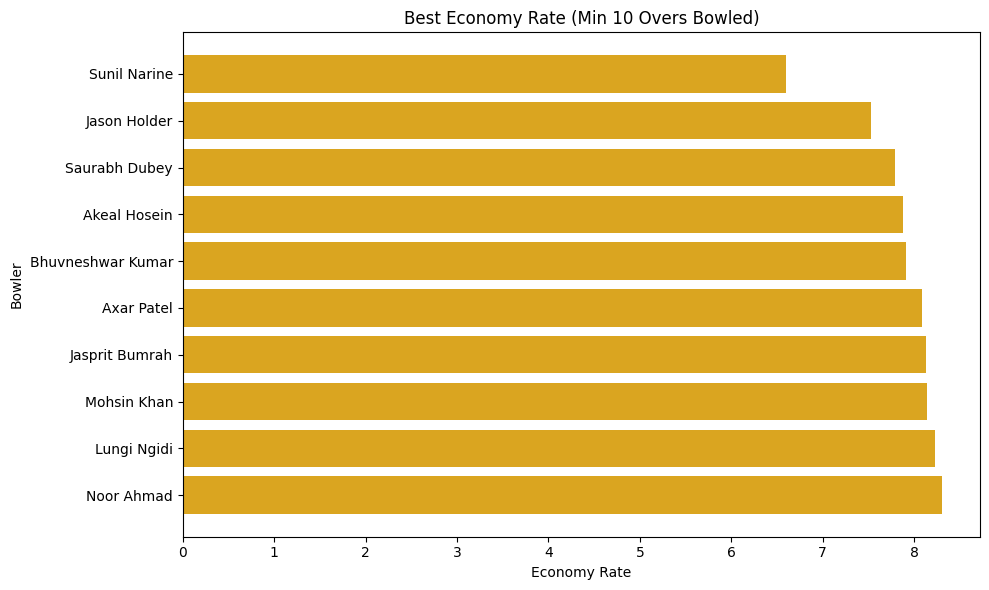

In [65]:
top_economy = economy_rate.loc[bowlers_qualified.index].sort_values().head(10)

plt.figure(figsize=(10,6))
plt.barh(top_economy.index, top_economy.values, color='goldenrod')
plt.title("Best Economy Rate (Min 10 Overs Bowled)")
plt.xlabel("Economy Rate")
plt.ylabel("Bowler")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

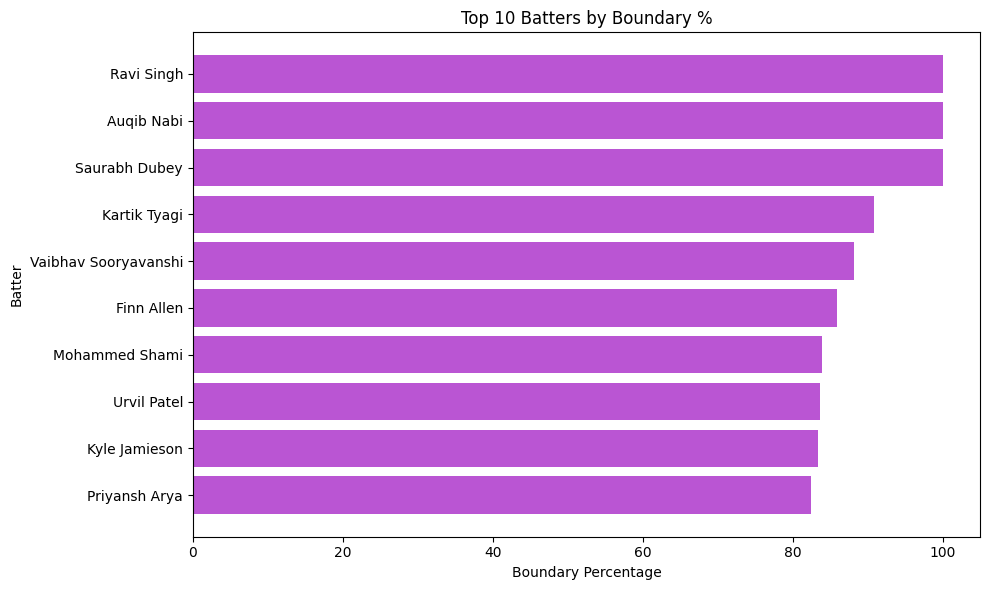

In [67]:
top_boundary = boundary_pct.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_boundary.index, top_boundary.values, color='mediumorchid')
plt.title("Top 10 Batters by Boundary %")
plt.xlabel("Boundary Percentage")
plt.ylabel("Batter")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Conclusion

This analysis of the IPL 2026 season (39 matches, 17,477 deliveries) revealed several clear patterns:

- **Toss strategy:** Teams overwhelmingly chose to bowl first after winning the toss (34 of 39 matches), and it paid off — bowling first led to a win 58.8% of the time, versus just 20% when choosing to bat first. Chasing was the dominant winning strategy this season.
- **Team performance:** RCB and PBKS led the season with 6 wins each.
- **Batting:** Vaibhav Sooryavanshi was the season's top run-scorer with 776 runs.
- **Bowling:** Bhuvneshwar Kumar, Jofra Archer, and Kagiso Rabada tied for the most wickets (29 each). Among bowlers with a meaningful sample size (10+ overs), Sunil Narine posted the best economy rate at 6.60.

Overall, the data suggests IPL 2026 was a chasing-friendly season, likely shaped by pitch or dew conditions favoring teams that bowled first.